In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from supabase import create_client, Client
from dotenv import load_dotenv
import os
from datetime import datetime, timedelta

plt.style.use("default")
sns.set_theme()


In [14]:
load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

TABLE_NAME = "tb_konsentrasi_gas"

COLS = [
    "created_at",
    "pm25_ugm3",
    "pm10_corrected_ugm3",
    "co_corrected_ugm3",
    "no2_ugm3",
    "temperature",
    "humidity"
]

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

print("Supabase client initialized.")


Supabase client initialized.


In [15]:
# Rentang waktu EDA (misal 14 hari terakhir)
DAYS = 14
start_date = datetime.now() - timedelta(days=DAYS)

page_size = 1000
offset = 0
all_data = []

print(f"Mengambil data sejak: {start_date}")

while True:
    response = supabase.table(TABLE_NAME) \
        .select(",".join(COLS)) \
        .gte("created_at", start_date.isoformat()) \
        .order("created_at", desc=False) \
        .range(offset, offset + page_size - 1) \
        .execute()

    batch = response.data
    if not batch:
        break

    all_data.extend(batch)
    offset += len(batch)
    print(f"Total data sementara: {len(all_data)}")

print(f"Total data akhir: {len(all_data)}")


Mengambil data sejak: 2025-12-01 11:35:42.780850
Total data sementara: 1000
Total data sementara: 2000
Total data sementara: 3000
Total data sementara: 4000
Total data sementara: 5000
Total data sementara: 6000
Total data sementara: 7000
Total data sementara: 8000
Total data sementara: 9000
Total data sementara: 10000
Total data sementara: 11000
Total data sementara: 12000
Total data sementara: 13000
Total data sementara: 14000
Total data sementara: 15000
Total data sementara: 16000
Total data sementara: 17000
Total data sementara: 18000
Total data sementara: 19000
Total data sementara: 19375
Total data akhir: 19375


In [17]:
df = pd.DataFrame(all_data)

# Konversi tipe data
df["created_at"] = pd.to_datetime(df["created_at"])

num_cols = [
    "pm25_ugm3", "pm10_corrected_ugm3",
    "co_corrected_ugm3", "no2_ugm3",
    "temperature", "humidity"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop NA
df.dropna(inplace=True)

df.set_index("created_at", inplace=True)
df.sort_index(inplace=True)

print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19375 entries, 2025-12-01 11:36:12.385131+00:00 to 2025-12-15 04:34:53.033489+00:00
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pm25_ugm3            19375 non-null  float64
 1   pm10_corrected_ugm3  19375 non-null  float64
 2   co_corrected_ugm3    19375 non-null  float64
 3   no2_ugm3             19375 non-null  float64
 4   temperature          19375 non-null  float64
 5   humidity             19375 non-null  float64
dtypes: float64(6)
memory usage: 1.0 MB
None


,pm25_ugm3,pm10_corrected_ugm3,co_corrected_ugm3,no2_ugm3,temperature,humidity
created_at,,,,,,
2025-12-01 11:36:12.385131+00:00,6.25,6.25,53.90556,94.09,34.7,62.1
2025-12-01 11:37:12.979566+00:00,3.26,3.76,54.41936,94.09,34.9,61.8
2025-12-01 11:38:13.629215+00:00,8.02,8.02,53.76855,94.09,34.7,61.9
2025-12-01 11:39:14.337105+00:00,6.61,6.61,54.35086,94.09,34.7,62.2
2025-12-01 11:40:15.051587+00:00,5.72,5.72,54.35086,94.09,34.9,61.8


In [18]:
df = pd.DataFrame(all_data)

# Konversi tipe data
df["created_at"] = pd.to_datetime(df["created_at"])

num_cols = [
    "pm25_ugm3", "pm10_corrected_ugm3",
    "co_corrected_ugm3", "no2_ugm3",
    "temperature", "humidity"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop NA
df.dropna(inplace=True)

df.set_index("created_at", inplace=True)
df.sort_index(inplace=True)

print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19375 entries, 2025-12-01 11:36:12.385131+00:00 to 2025-12-15 04:34:53.033489+00:00
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pm25_ugm3            19375 non-null  float64
 1   pm10_corrected_ugm3  19375 non-null  float64
 2   co_corrected_ugm3    19375 non-null  float64
 3   no2_ugm3             19375 non-null  float64
 4   temperature          19375 non-null  float64
 5   humidity             19375 non-null  float64
dtypes: float64(6)
memory usage: 1.0 MB
None


,pm25_ugm3,pm10_corrected_ugm3,co_corrected_ugm3,no2_ugm3,temperature,humidity
created_at,,,,,,
2025-12-01 11:36:12.385131+00:00,6.25,6.25,53.90556,94.09,34.7,62.1
2025-12-01 11:37:12.979566+00:00,3.26,3.76,54.41936,94.09,34.9,61.8
2025-12-01 11:38:13.629215+00:00,8.02,8.02,53.76855,94.09,34.7,61.9
2025-12-01 11:39:14.337105+00:00,6.61,6.61,54.35086,94.09,34.7,62.2
2025-12-01 11:40:15.051587+00:00,5.72,5.72,54.35086,94.09,34.9,61.8


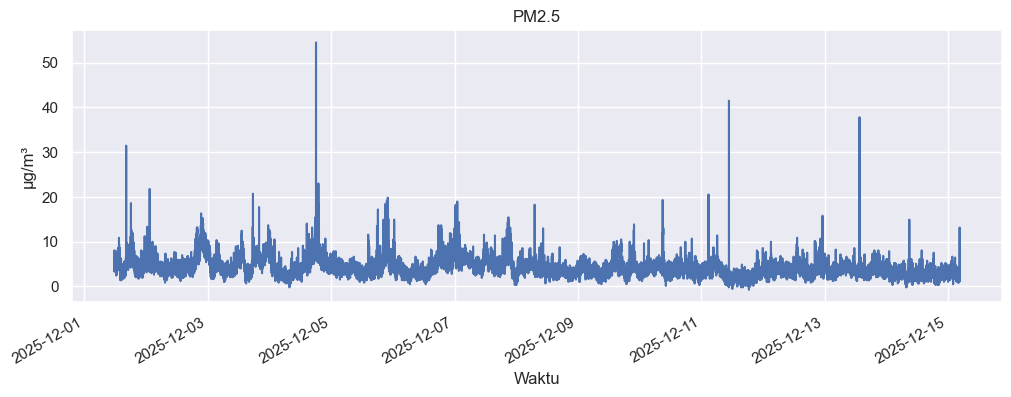

In [25]:
plt.figure(figsize=(12,4))
df["pm25_ugm3"].plot()
plt.title("PM2.5")
plt.ylabel("µg/m³")
plt.xlabel("Waktu")
plt.show()


In [20]:
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
pm25_ugm3,19375.0,4.158040,2.014020e+00,-0.80000,2.90000,3.79000,5.02000,54.54000
pm10_corrected_ugm3,19375.0,4.300453,2.420578e+00,-0.80000,2.90000,3.96000,5.20000,90.41000
co_corrected_ugm3,19375.0,58.011925,2.208831e+00,47.67142,56.52596,57.74195,59.21486,75.24552
no2_ugm3,19375.0,94.090000,1.421122e-14,94.09000,94.09000,94.09000,94.09000,94.09000
temperature,19375.0,33.668655,1.451640e+00,30.50000,32.50000,33.70000,34.80000,40.10000
humidity,19375.0,62.221801,5.446465e+00,41.90000,58.90000,63.40000,66.30000,72.70000


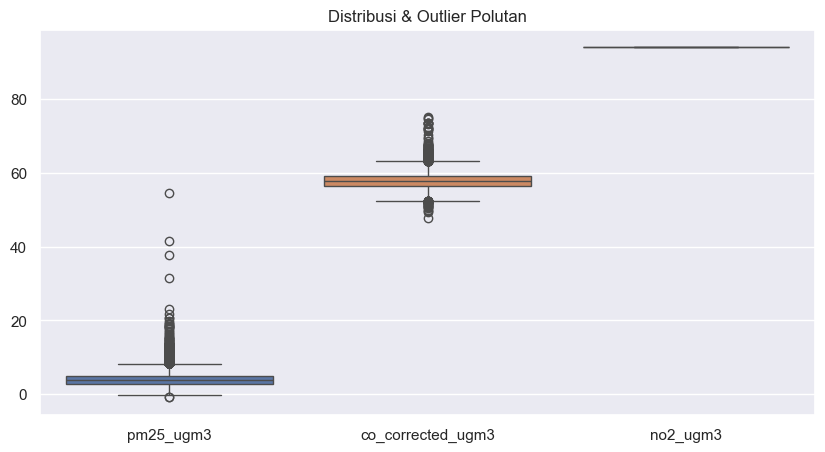

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[["pm25_ugm3", "co_corrected_ugm3", "no2_ugm3"]])
plt.title("Distribusi & Outlier Polutan")
plt.show()


In [10]:
missing_ratio = df.isna().mean() * 100
missing_ratio


pm25_ugm3              0.0
pm10_corrected_ugm3    0.0
co_ugm3                0.0
no2_ugm3               0.0
temperature            0.0
humidity               0.0
dtype: float64

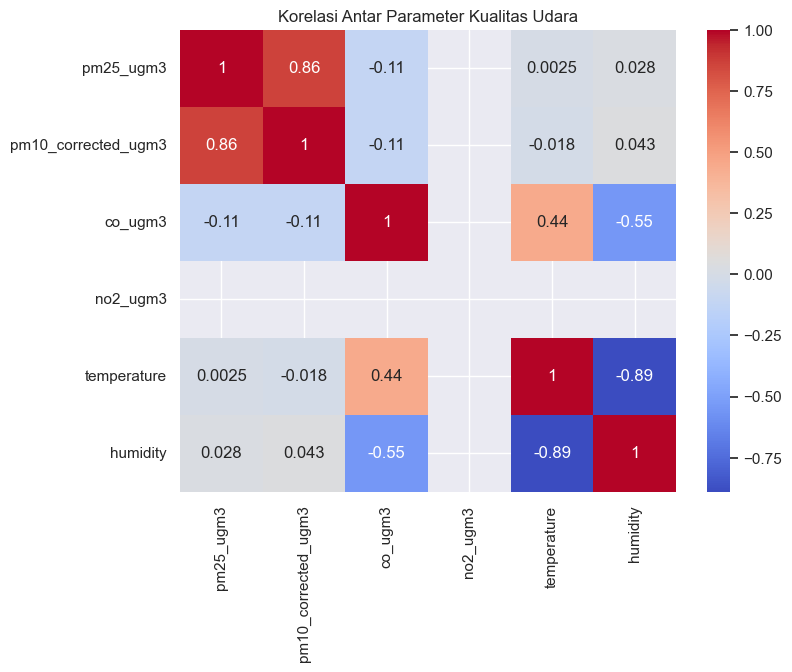

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Korelasi Antar Parameter Kualitas Udara")
plt.show()


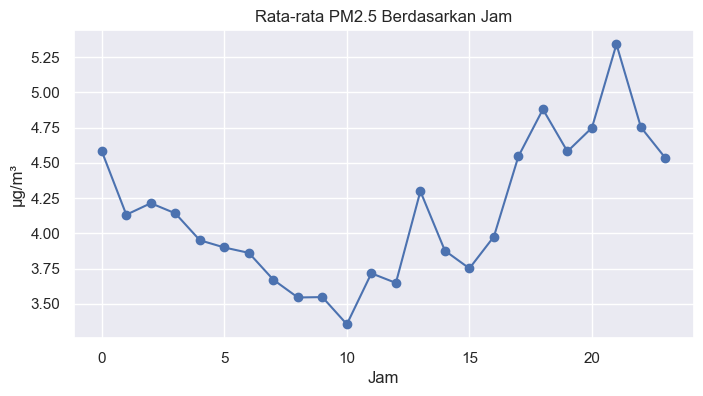

In [12]:
df["hour"] = df.index.hour

hourly_mean = df.groupby("hour")["pm25_ugm3"].mean()

plt.figure(figsize=(8,4))
hourly_mean.plot(marker="o")
plt.title("Rata-rata PM2.5 Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("µg/m³")
plt.grid(True)
plt.show()
